In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from astropy.io import fits
from astropy.io import fits
from astropy.table import Table
import json
import sys

In [2]:
sys.path.append(str(Path().resolve() / 'py_modules')) 

import list_maps_plots

#  Data

In [3]:
line        = r'H$\alpha$'
lambda_rest = 6562.8
line_id     = 'H'
line_id2   = "6563"

In [4]:
#line        = r'[O II] $\lambda$3726'
#lambda_rest = 3726.03 
#line_id     = 'OIIb'
#line_id2   = "3726"

In [5]:
#line        = r'[O II] $\lambda$3729'
#lambda_rest = 3728.80 
#line_id     = 'OIIa'
#line_id2   = "3729"

In [6]:
#line        = r'[O III]$\lambda$ 5007'
#lambda_rest = 5006.9
#line_id     = 'OIIIa'
#line_id2   = "5007"

In [7]:
# Data from observations
bins        = 0

region     = 'NGC 2070'
name_reg   = '30 Doradus'
reg_id     = '30Dor'
inst       = 'LVM'
inst_id    = 'LVM'
type_obj   = 'H II region'

pix        = 0   # Instrument resolution [arcsec/pix]
dist       = 50000 # Distance [parsecs]
s0_        = 0.9    # proposed seeing

pc         = dist*(2*np.pi) / (360 * 60 * 60)
s0         = (s0_*pc)

#Since we are working with scatter adata there is no binning that can be applied
name_file    =  inst_id + '-' + reg_id + '-' + line_id2
name_id      =  inst_id + '-' + reg_id + '-' + line_id + "-X"
print(name_file)
print(name_id)


LVM-30Dor-6563
LVM-30Dor-H-X


In [8]:
_data = json.load(open('observations/'+ name_file + '-l.json'))
_line = pd.DataFrame(_data['data'])
_line.columns = ['RAdeg', 'DEdeg', 'V_mean','log_F','sigma']
#_line = _line[0:3500]

In [9]:
#_line

In [10]:
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.wcs import WCS

c0 = SkyCoord.from_name("Tarantula")
c0

<SkyCoord (ICRS): (ra, dec) in deg
    (84.675, -69.1)>

In [11]:
fov_deg = 1.0  # Total field of view in degrees (width and height)
pix_scale = 1 / 3600
npix = int(fov_deg / pix_scale)

# Create WCS for TAN projection centered at 'center'
wcs = WCS(naxis=2)
wcs.wcs.ctype = ["RA---TAN", "DEC--TAN"]
wcs.wcs.crval = [c0.ra.deg, c0.dec.deg]
wcs.wcs.crpix = [npix, npix]  # center of your "image"
wcs.wcs.cdelt = [-pix_scale, pix_scale]  # field size / pixel count

In [12]:
ra0  = c0.ra.deg
dec0 = c0.dec.deg
#ra0 = _line["RAdeg"].median()
#dec0 = _line["DEdeg"].median()
print(ra0, dec0)

84.675 -69.1


In [13]:

centro = SkyCoord(ra=ra0*u.deg, dec=dec0*u.deg, frame='icrs')

coords = SkyCoord(
    ra=_line["RAdeg"].values * u.deg,
    dec=_line["DEdeg"].values * u.deg,
    frame='icrs'
)

radio = 2000 * u.arcsec   
sep = coords.separation(centro)

line_rad = _line[sep <= radio]


In [14]:
mu = line_rad["V_mean"].mean()
sigma = line_rad["V_mean"].std()
n = 3.0

#line_mask = line_rad[np.log10(line_rad["log_F"]) > 0.5]
line_mask = line_rad[(line_rad["log_F"] > 1000) &
    (line_rad["V_mean"] > (mu - n*sigma)) & (line_rad["V_mean"] < (mu + n*sigma))]


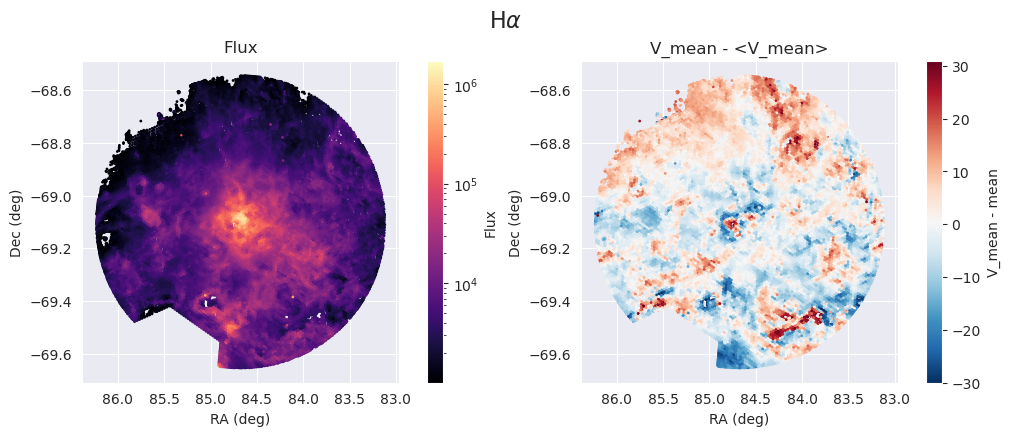

<Figure size 640x480 with 0 Axes>

In [15]:
fig, ax = list_maps_plots.plot_panels_log_title(line_mask,
                                                s=1.0,
                                                figsize=(10, 4.25),
                                                titles=("Flux", "V_mean - <V_mean>"),
                                                figure_title=line)
plt.show()
plt.savefig('Imgs/' + name_file + '.jpg', bbox_inches='tight')

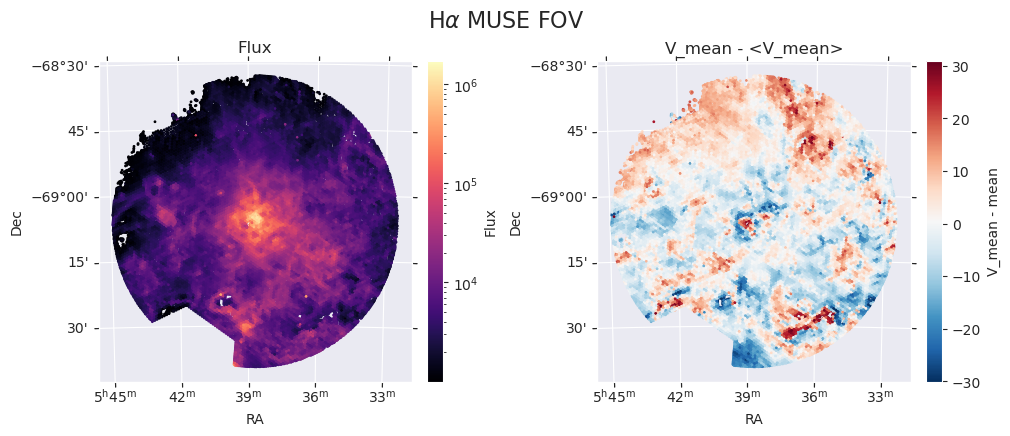

<Figure size 640x480 with 0 Axes>

In [16]:
fig, ax = list_maps_plots.plot_panels_wcs(line_mask,
                                          wcs,
                                          s=1.0,
                                          figsize=(10, 4.25),
                                          invert_ra=False, 
                                          titles=("Flux", "V_mean - <V_mean>"),
                                          figure_title=line +' MUSE FOV')
plt.show()

plt.savefig('Imgs/' + name_file + '.jpg', bbox_inches='tight')

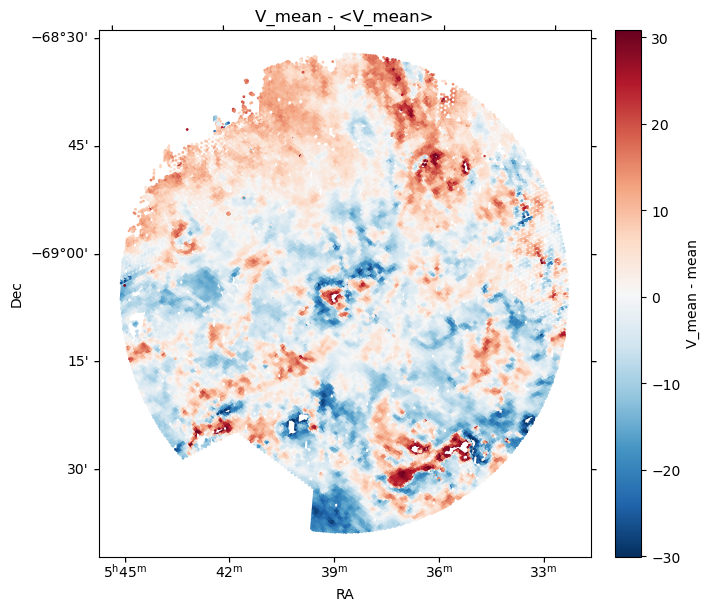

In [17]:
import matplotlib.pyplot as plt

v1 = line_mask["V_mean"] - line_mask["V_mean"].mean()

fig = plt.figure(figsize=(7, 6), constrained_layout=True)
ax = fig.add_subplot(1, 1, 1, projection=wcs)

sc = ax.scatter(
    line_mask["RAdeg"],
    line_mask["DEdeg"],
    s=1.0,
    c=v1,
    cmap="RdBu_r",
    transform=ax.get_transform("world")
)

ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.set_title("V_mean - <V_mean>")
#ax.invert_xaxis()   # use this only if needed

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("V_mean - mean")

# Division

In [18]:
radius = 413*u.arcsec
pa = 45 * u.deg # position angle
new_center = centro.directional_offset_by(pa, 2*radius)

## Init test plot circles

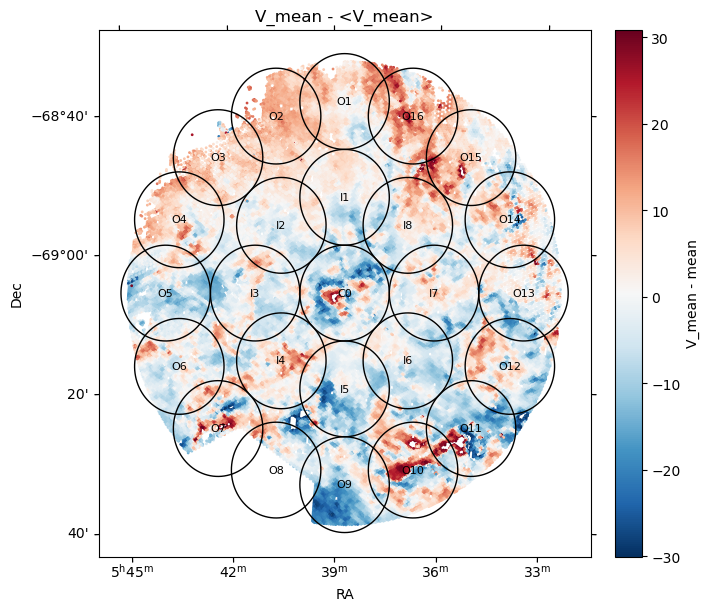

In [19]:
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.visualization.wcsaxes.patches import SphericalCircle

v1 = line_mask["V_mean"] - line_mask["V_mean"].mean()

fig = plt.figure(figsize=(7, 6), constrained_layout=True)
ax = fig.add_subplot(1, 1, 1, projection=wcs)

sc = ax.scatter(
    line_mask["RAdeg"],
    line_mask["DEdeg"],
    s=1.0,
    c=v1,
    cmap="RdBu_r",
    transform=ax.get_transform("world")
)

r = radius   # e.g. 413 * u.arcsec

# -------------------------
# central circle
# -------------------------
circle_center = SphericalCircle(
    (centro.ra, centro.dec),
    r,
    edgecolor="black",
    facecolor="none",
    linewidth=1,
    transform=ax.get_transform("world")
)
ax.add_patch(circle_center)

ax.text(
    centro.ra.deg,
    centro.dec.deg,
    "C0",
    transform=ax.get_transform("world"),
    ha="center",
    va="center",
    fontsize=8,
    color="black"
)

# -------------------------
# inner circles
# -------------------------
d_in = 2 * r
angles_in = [0, 45, 90, 135, 180, 225, 270, 315] * u.deg

for i, pa in enumerate(angles_in, start=1):
    c = centro.directional_offset_by(pa, d_in)

    circle_in = SphericalCircle(
        (c.ra, c.dec),
        r,
        edgecolor="black",
        facecolor="none",
        linewidth=1,
        transform=ax.get_transform("world")
    )
    ax.add_patch(circle_in)

    ax.text(
        c.ra.deg,
        c.dec.deg,
        f"I{i}",
        transform=ax.get_transform("world"),
        ha="center",
        va="center",
        fontsize=8,
        color="black"
    )

# -------------------------
# outer circles
# -------------------------
d_out = 4 * r
angles_out = [0, 22.5,
              45, 67.5,
              90, 112.5,
              135, 157.5,
              180, 202.5,
              225, 247.5,
              270, 292.5,
              315, 337.5] * u.deg

for i, pa in enumerate(angles_out, start=1):
    c = centro.directional_offset_by(pa, d_out)

    circle_out = SphericalCircle(
        (c.ra, c.dec),
        r,
        edgecolor="black",
        facecolor="none",
        linewidth=1,
        transform=ax.get_transform("world")
    )
    ax.add_patch(circle_out)

    ax.text(
        c.ra.deg,
        c.dec.deg,
        f"O{i}",
        transform=ax.get_transform("world"),
        ha="center",
        va="center",
        fontsize=8,
        color="black"
    )

ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.set_title("V_mean - <V_mean>")

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("V_mean - mean")

## Adding circles with metadata

In [20]:

r = radius

circles = []

# central circle
circles.append({
    "label": "C0",
    "ring": "center",
    "angle_deg": None,
    "center": centro,
    "ra_deg": centro.ra.deg,
    "dec_deg": centro.dec.deg,
    "radius_arcsec": r.to(u.arcsec).value,
})

# inner ring
d_in = 2 * r
angles_in = [0, 45, 90, 135, 180, 225, 270, 315] * u.deg

for i, pa in enumerate(angles_in, start=1):
    c = centro.directional_offset_by(pa, d_in)
    circles.append({
        "label": f"I{i}",
        "ring": "inner",
        "angle_deg": pa.to(u.deg).value,
        "center": c,
        "ra_deg": c.ra.deg,
        "dec_deg": c.dec.deg,
        "radius_arcsec": r.to(u.arcsec).value,
    })

# outer ring
d_out = 4 * r
angles_out = [0, 22.5,
              45, 67.5,
              90, 112.5,
              135, #157.5,
              180, 202.5,
              225, 247.5,
              270, 292.5,
              315, 337.5] * u.deg

for i, pa in enumerate(angles_out, start=1):
    c = centro.directional_offset_by(pa, d_out)
    circles.append({
        "label": f"O{i}",
        "ring": "outer",
        "angle_deg": pa.to(u.deg).value,
        "center": c,
        "ra_deg": c.ra.deg,
        "dec_deg": c.dec.deg,
        "radius_arcsec": r.to(u.arcsec).value,
    })

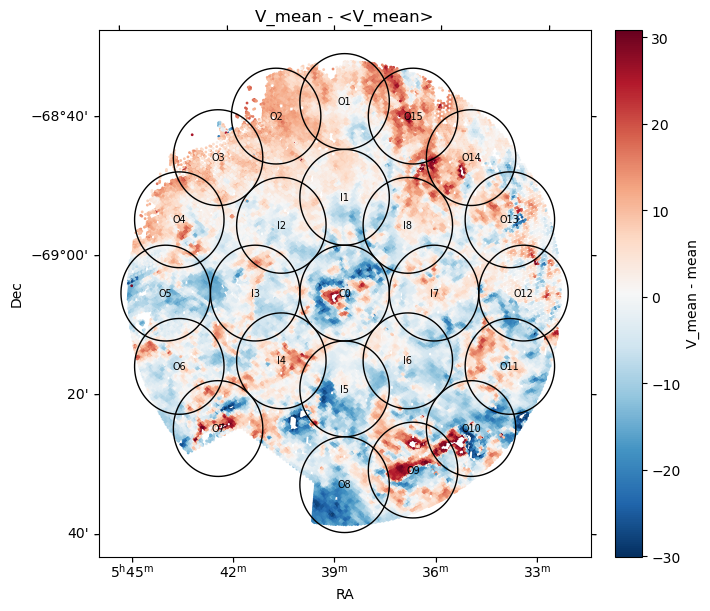

In [21]:
import matplotlib.pyplot as plt
from astropy.visualization.wcsaxes.patches import SphericalCircle

v1 = line_mask["V_mean"] - line_mask["V_mean"].mean()

fig = plt.figure(figsize=(7, 6), constrained_layout=True)
ax = fig.add_subplot(1, 1, 1, projection=wcs)

sc = ax.scatter(
    line_mask["RAdeg"],
    line_mask["DEdeg"],
    s=1.0,
    c=v1,
    cmap="RdBu_r",
    transform=ax.get_transform("world")
)

for item in circles:
    circle = SphericalCircle(
        (item["center"].ra, item["center"].dec),
        item["radius_arcsec"] * u.arcsec,
        edgecolor="black",
        facecolor="none",
        linewidth=1,
        transform=ax.get_transform("world")
    )
    ax.add_patch(circle)

    ax.text(
        item["ra_deg"],
        item["dec_deg"],
        item["label"],
        transform=ax.get_transform("world"),
        ha="center",
        va="center",
        fontsize=7,
        color="black"
    )

ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.set_title("V_mean - <V_mean>")

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("V_mean - mean")

In [22]:
circles[0]

{'label': 'C0',
 'ring': 'center',
 'angle_deg': None,
 'center': <SkyCoord (ICRS): (ra, dec) in deg
     (84.675, -69.1)>,
 'ra_deg': 84.675,
 'dec_deg': -69.1,
 'radius_arcsec': 413.0}

In [23]:
circles[1]

{'label': 'I1',
 'ring': 'inner',
 'angle_deg': 0.0,
 'center': <SkyCoord (ICRS): (ra, dec) in deg
     (84.675, -68.87055556)>,
 'ra_deg': 84.675,
 'dec_deg': -68.87055555555555,
 'radius_arcsec': 413.0}

In [24]:
circles[2]

{'label': 'I2',
 'ring': 'inner',
 'angle_deg': 45.0,
 'center': <SkyCoord (ICRS): (ra, dec) in deg
     (85.1264378, -68.93716139)>,
 'ra_deg': 85.1264378029564,
 'dec_deg': -68.93716138661414,
 'radius_arcsec': 413.0}

# Data for each circle

In [30]:
coords_all = SkyCoord(
    ra=line_mask["RAdeg"].values * u.deg,
    dec=line_mask["DEdeg"].values * u.deg,
    frame="icrs"
)

In [31]:
regions_data = {}

for circle in circles:
    radius_u = circle["radius_arcsec"] * u.arcsec
    sep = coords_all.separation(circle["center"])
    
    df_circle = line_mask.loc[sep <= radius_u].copy()
    
    regions_data[circle["label"]] = df_circle

In [35]:

for circle in circles:
    label = circle["label"]
    ring = circle["ring"]
    angle_deg = circle["angle_deg"]
    circle_center = circle["center"]
    circle_radius = circle["radius_arcsec"] * u.arcsec

    # mask data inside this circle
    sep = coords_all.separation(circle_center)
    df_circle = line_mask.loc[sep <= circle_radius].copy()

    # skip empty regions
    if df_circle.empty:
        print(f"Skipping {label}: no data points inside circle.")
        continue

    # compute region-specific parameters
    N = np.sqrt(
        (df_circle.RAdeg.max() - df_circle.RAdeg.min()) *
        (df_circle.DEdeg.max() - df_circle.DEdeg.min())
    ) * pc * 3600

    sig = df_circle["V_mean"].std()

    # define output name
    circle_name_file = f"{name_file}_{label}"
    circle_name_id = f"{name_id}_{label}"

    # table HDU
    t = Table.from_pandas(df_circle.reset_index(drop=True))
    table_hdu = fits.BinTableHDU(t, name=circle_name_file)

    # primary HDU
    primary = fits.PrimaryHDU()
    hdr = primary.header

    hdr["FILE"]      = (circle_name_file, "Fits file name")
    hdr["NAME_ID"]   = (circle_name_id, "pipeline identifier")
    hdr["REG"]       = (region, "Region catalog name")
    hdr["NAME_REG"]  = (name_reg, "Region name")
    hdr["REG_ID"]    = (reg_id, "Region identifier")
    hdr["TYPE_OBJ"]  = (type_obj, "Type object")
    hdr["DIST"]      = (dist, "Distance in parsecs")
    hdr["INSTR"]     = (inst, "Instrument")
    hdr["LINE"]      = (line, "Emission line name")
    hdr["LINE_ID"]   = (line_id, "Emission line identifier")
    hdr["L_REST"]    = (lambda_rest, "Emission line rest wavelength")
    hdr["SIG"]       = (sig, "Standard deviation vel map")
    hdr["SIG2"]      = (sig**2, "Vel variance map")
    hdr["S0"]        = (s0, "Atmospheric seeing")
    hdr["BOX_SIZE"]  = (N, "Observational box_size")
    hdr["PC"]        = (pc, "parsec conversion")
    hdr["PIX"]       = (pix, "Instrument pixel scale")
    hdr["BINSIZE"]   = (bins, "Spatial binning factor")

    # circle metadata
    hdr["CIRC_ID"]   = (label, "Circle identifier")
    hdr["CIRCRING"]  = (ring, "Circle ring")
    hdr["CIRC_RA"]   = (circle_center.ra.deg, "Circle center RA deg")
    hdr["CIRC_DEC"]  = (circle_center.dec.deg, "Circle center Dec deg")
    hdr["CIRC_RAD"]  = (circle_radius.to(u.arcsec).value, "Circle radius arcsec")
    hdr["AUTHOR"]    = ("J. Garcia-Vazquez", "File creator")

    if angle_deg is not None:
        hdr["CIRC_PA"] = (angle_deg, "Circle position angle deg")

    hdul = fits.HDUList([primary, table_hdu])
    hdul.writeto(f"fits_ready/{circle_name_file}.fits", overwrite=True)

    print(f"Saved: fits_ready/{circle_name_file}.fits  ({len(df_circle)} rows)")

Saved: fits_ready/LVM-30Dor-6563_C0.fits  (5375 rows)
Saved: fits_ready/LVM-30Dor-6563_I1.fits  (5002 rows)
Saved: fits_ready/LVM-30Dor-6563_I2.fits  (4832 rows)
Saved: fits_ready/LVM-30Dor-6563_I3.fits  (5077 rows)
Saved: fits_ready/LVM-30Dor-6563_I4.fits  (4555 rows)
Saved: fits_ready/LVM-30Dor-6563_I5.fits  (4301 rows)
Saved: fits_ready/LVM-30Dor-6563_I6.fits  (4790 rows)
Saved: fits_ready/LVM-30Dor-6563_I7.fits  (4607 rows)
Saved: fits_ready/LVM-30Dor-6563_I8.fits  (4440 rows)
Saved: fits_ready/LVM-30Dor-6563_O1.fits  (3221 rows)
Saved: fits_ready/LVM-30Dor-6563_O2.fits  (3238 rows)
Saved: fits_ready/LVM-30Dor-6563_O3.fits  (2817 rows)
Saved: fits_ready/LVM-30Dor-6563_O4.fits  (3942 rows)
Saved: fits_ready/LVM-30Dor-6563_O5.fits  (3935 rows)
Saved: fits_ready/LVM-30Dor-6563_O6.fits  (3844 rows)
Saved: fits_ready/LVM-30Dor-6563_O7.fits  (2516 rows)
Saved: fits_ready/LVM-30Dor-6563_O8.fits  (3799 rows)
Saved: fits_ready/LVM-30Dor-6563_O9.fits  (4146 rows)
Saved: fits_ready/LVM-30Dor-

In [33]:
import pandas as pd

circles_df = pd.DataFrame([
    {
        "label": c["label"],
        "ring": c["ring"],
        "angle_deg": c["angle_deg"],
        "ra_deg": c["ra_deg"],
        "dec_deg": c["dec_deg"],
        "radius_arcsec": c["radius_arcsec"],
    }
    for c in circles
])

circles_df.to_csv("fits_ready/circle_catalog.csv", index=False)

In [34]:
export_names = [f"{name_file}_{circle['label']}" for circle in circles]

with open("fits_ready/filelist_circles.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(export_names) + "\n")

In [25]:
xxx

NameError: name 'xxx' is not defined

# Export

In [ ]:
N = np.sqrt((line_mask.RAdeg.max()-line_mask.RAdeg.min())*(line_mask.DEdeg.max()-line_mask.DEdeg.min())) * pc * 3600
sig       = line_mask['V_mean'].std()

In [ ]:
t         = Table.from_pandas(line_mask.reset_index(drop=True))
table_hdu = fits.BinTableHDU(t, name=name_file)

In [ ]:
primary = fits.PrimaryHDU()
primary.header["FILE"]       = (name_file, "Fits file name")
primary.header["NAME_ID"]    = (name_id, "pipeline identifier")
primary.header["REG"]        = (region, "Region catalog name")
primary.header["NAME_REG"]   = (name_reg, "Region name")
primary.header["REG_ID"]     = (reg_id, "Region identifier")
primary.header["TYPE_OBJ"]   = (type_obj, "Type object")
primary.header["DIST"]       = (dist, "Distance in parsecs")
primary.header["INSTR"]      = (inst, "Instrument")
primary.header["LINE"]       = (line, "Emission line name")
primary.header["LINE_ID"]    = (line_id, "Emission line identifier")
primary.header["L_REST"]= (lambda_rest, "Emission line name")
primary.header["SIG"]        = (sig, "Standard deviation vel map")
primary.header["SIG2"]       = (sig**2, "Vel Variance map")
primary.header["S0"]         = (s0, "Atmospheric seeing")
primary.header["BOX_SIZE"]   = (N, "Observational box_size")
primary.header["PC"]         = (pc, "parsec convertion")
primary.header["PIX"]        = (pix, "Instrument pixel scale")
primary.header["BINSIZE"]    = (bins, "Spatial binning factor")
#hdr["noise"]     = (noise, "Instrumental noise")
#hdr["m3D"]       = (m3D, "k = 3 + m3D")
#hdr["ra"]        = (ra, "Artificial correlation length")
#primary.header["SEED1"]     = (randomseed_vv, "Random seed velocity")
#primary.header["SEED2"]     = (randomseed_sb, "Random seed surfavebrightness")
primary.header["AUTHOR"]     = ("J. Garcia-Vazquez", "File creator")

In [ ]:
hdul = fits.HDUList([primary, table_hdu])
hdul.writeto("fits_ready/" + name_file + ".fits", overwrite=True)

In [ ]:
with fits.open("fits_ready/" + name_file + ".fits") as hdul:
    hdul.info()